<a href="https://colab.research.google.com/github/rosh4nn/ML-Regression-StudentsPerformance-Project/blob/main/StudentsPerformance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [ ]:
df.shape

(10000, 6)

In [ ]:
df[df.duplicated()]

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
915,9,52,No,5,9,48.0
1477,7,61,Yes,6,8,54.0
1601,5,99,No,7,5,89.0
1786,2,62,Yes,9,4,40.0
2026,5,87,Yes,6,7,74.0
...,...,...,...,...,...,...
9644,4,91,Yes,4,3,71.0
9940,8,95,No,5,2,90.0
9954,6,97,No,8,7,92.0
9966,1,41,No,7,3,12.0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df[df.duplicated()]

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index


In [ ]:
df.isna().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [ ]:
df.columns = df.columns.str.replace(' ','_')

In [ ]:
df['Extracurricular_Activities'] = df['Extracurricular_Activities'].replace({'Yes':1,'No':0})

/tmp/ipykernel_10003/116751439.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Extracurricular_Activities'] = df['Extracurricular_Activities'].replace({'Yes':1,'No':0})


In [ ]:
df['Extracurricular_Activities'].unique()

array([1, 0])

In [ ]:
df.corr()['Performance_Index']

,Performance_Index
Hours_Studied,0.375332
Previous_Scores,0.915135
Extracurricular_Activities,0.026075
Sleep_Hours,0.050352
Sample_Question_Papers_Practiced,0.043436
Performance_Index,1.000000


In [ ]:
x = df.drop(columns=['Extracurricular_Activities','Performance_Index'])
x

,Hours_Studied,Previous_Scores,Sleep_Hours,Sample_Question_Papers_Practiced
0,7,99,9,1
1,4,82,4,2
2,8,51,7,2
3,5,52,5,2
4,7,75,8,5
...,...,...,...,...
9995,1,49,4,2
9996,7,64,8,5
9997,6,83,8,5
9998,9,97,7,0


In [ ]:
y = df.iloc[:,-1]
y

,Performance_Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0
...,...
9995,23.0
9996,58.0
9997,74.0
9998,95.0


In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model

LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)
y_pred

array([55.64203544, 46.85277462, 66.91199338, ..., 39.89265924,
       64.30390664, 84.79352716])

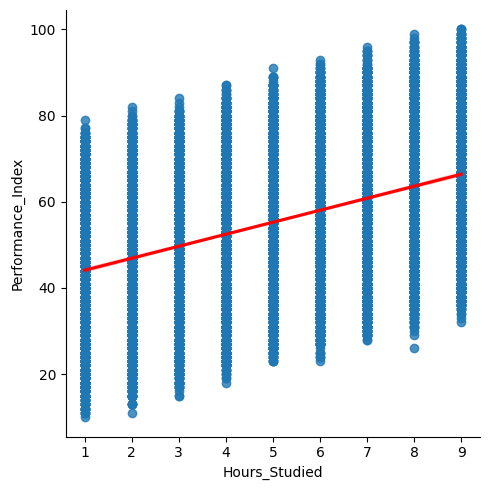

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lmplot(x='Hours_Studied',y='Performance_Index',data=df,line_kws={'color':'red'})
plt.show()

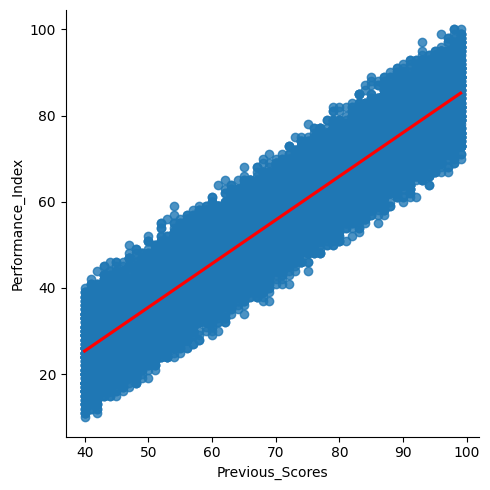

In [ ]:
sns.lmplot(x='Previous_Scores',y='Performance_Index',data=df,line_kws={'color':'red'})
plt.show()

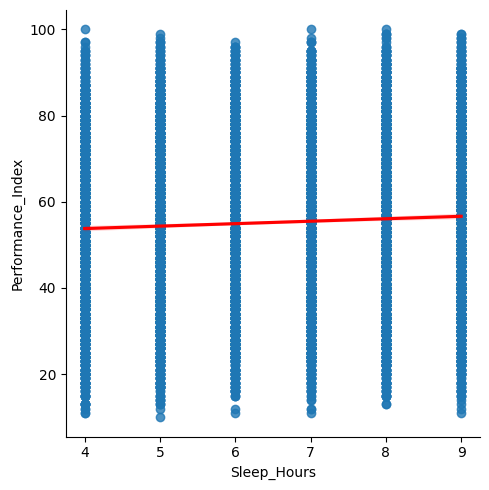

In [ ]:
sns.lmplot(x='Sleep_Hours',y='Performance_Index',data=df,line_kws={'color':'red'})
plt.show()

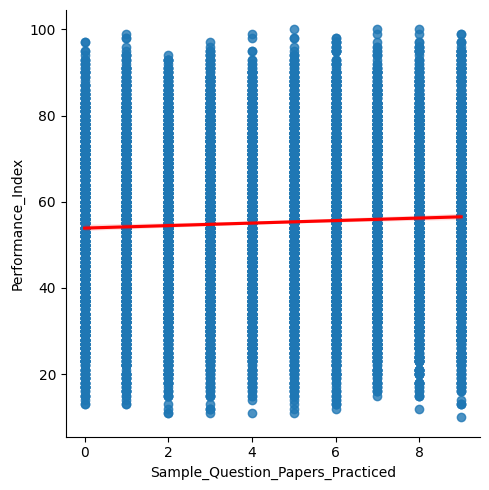

In [ ]:
sns.lmplot(x='Sample_Question_Papers_Practiced',y='Performance_Index',data=df,line_kws={'color':'red'})
plt.show()

In [ ]:
print(model.coef_)
print(model.intercept_)

[2.85244608 1.01825471 0.4817015  0.18826278]
-33.75163687612385


In [ ]:
ypred = (2.85244608*5)+(1.01825471*70)+(0.4817015*8)+(0.18826278*0)+-33.75163687612385
ypred

55.64203522387616

In [ ]:
y_pred[0]

np.float64(55.6420354403896)

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

print(f"R2_score: {r2_score(y_test,y_pred)}")
print(f"mean_absolute_error: {mean_absolute_error(y_test,y_pred)}")
print(f"mean_squared_error: {mean_squared_error(y_test,y_pred)}")
print(f"root_mean_squared_error: {root_mean_squared_error(y_test,y_pred)}")

R2_score: 0.9887137247544682
mean_absolute_error: 1.6274712206280653
mean_squared_error: 4.1977896792772835
root_mean_squared_error: 2.0488508191855463
